# Dataset



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-dataset' dataset.
Path to dataset files: /kaggle/input/employee-dataset


In [2]:
import pandas as pd
path = '/kaggle/input/employee-dataset/Employee.csv'
data = pd.read_csv(path)
data.head()


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


# Data Quality Assessment

In [3]:
# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data.shape

(4653, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [6]:
data.isnull().sum()  # null values

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [7]:
data.duplicated().sum()  # duplicate values

np.int64(1889)

In [8]:
data.describe()  #statistical summary

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [9]:
data.describe(include='object') #categorical summary

,Education,City,Gender,EverBenched
count,4653,4653,4653,4653
unique,3,3,2,2
top,Bachelors,Bangalore,Male,No
freq,3601,2228,2778,4175


In [10]:
data.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

In [11]:
for col in data.columns:
    print(col , data[col].unique())


Education ['Bachelors' 'Masters' 'PHD']
JoiningYear [2017 2013 2014 2016 2015 2012 2018]
City ['Bangalore' 'Pune' 'New Delhi']
PaymentTier [3 1 2]
Age [34 28 38 27 24 22 23 37 32 39 29 30 36 31 25 26 40 35 33 41]
Gender ['Male' 'Female']
EverBenched ['No' 'Yes']
ExperienceInCurrentDomain [0 3 2 5 1 4 7 6]
LeaveOrNot [0 1]


# Data Cleaning

In [12]:
data.shape

(4653, 9)

In [13]:
data = data.drop_duplicates() # remove duplicates

In [14]:
data.shape

(2764, 9)

In [15]:
# standardize column names
data.columns = (
    data.columns
        .str.lower()
        .str.strip()
)

In [16]:
# new attrition column
data['attrition'] = data['leaveornot'].map({
    0: 'Stayed',
    1: 'Left'
})

In [17]:
data.head()

,education,joiningyear,city,paymenttier,age,gender,everbenched,experienceincurrentdomain,leaveornot,attrition
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,Stayed
1,Bachelors,2013,Pune,1,28,Female,No,3,1,Left
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,Stayed
3,Masters,2016,Bangalore,3,27,Male,No,5,1,Left
4,Masters,2017,Pune,3,24,Male,Yes,2,1,Left


In [18]:
data.to_csv('employee_clean.csv',index=False)


# Exploratory Data Analysis

In [19]:
data = pd.read_csv('employee_clean.csv')
data.head()

,education,joiningyear,city,paymenttier,age,gender,everbenched,experienceincurrentdomain,leaveornot,attrition
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,Stayed
1,Bachelors,2013,Pune,1,28,Female,No,3,1,Left
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,Stayed
3,Masters,2016,Bangalore,3,27,Male,No,5,1,Left
4,Masters,2017,Pune,3,24,Male,Yes,2,1,Left


In [20]:
# Attrition rate for each column


for col in data.columns:
    if col != 'attrition'and col !='leaveornot':
        col_attrition = pd.crosstab(
            data[col],
            data['attrition'],
            normalize='index'
        )*100

        print(f'Attrition for {col}\n {col_attrition}\n')
        print("-------------------------------\n")

Attrition for education
 attrition       Left     Stayed
education                      
Bachelors  37.493658  62.506342
Masters    48.508634  51.491366
PHD        25.641026  74.358974

-------------------------------

Attrition for joiningyear
 attrition         Left     Stayed
joiningyear                      
2012         26.948052  73.051948
2013         43.181818  56.818182
2014         30.909091  69.090909
2015         41.379310  58.620690
2016         28.387097  71.612903
2017         30.362538  69.637462
2018         97.907950   2.092050

-------------------------------

Attrition for city
 attrition       Left     Stayed
city                           
Bangalore  35.012810  64.987190
New Delhi  34.090909  65.909091
Pune       50.936330  49.063670

-------------------------------

Attrition for paymenttier
 attrition         Left     Stayed
paymenttier                      
1            35.321101  64.678899
2            60.175439  39.824561
3            33.805668  66.194332

--

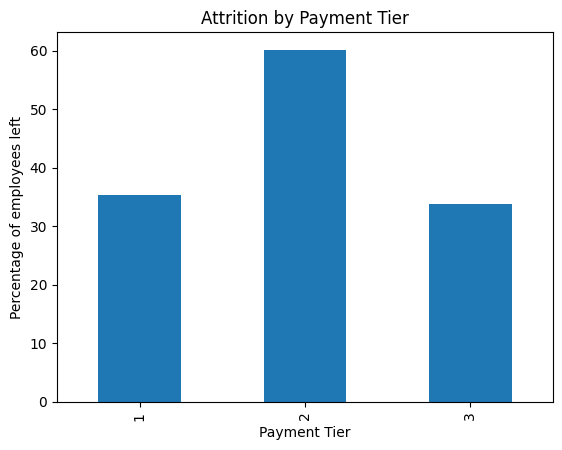

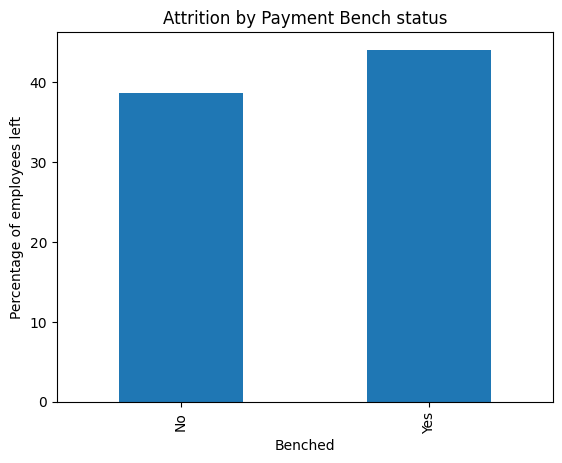

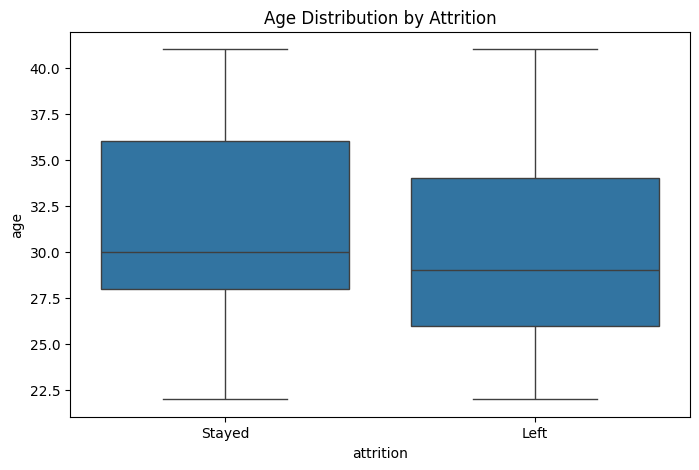

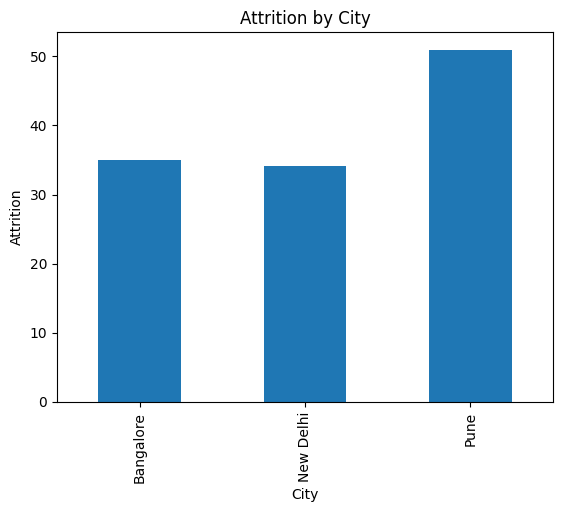

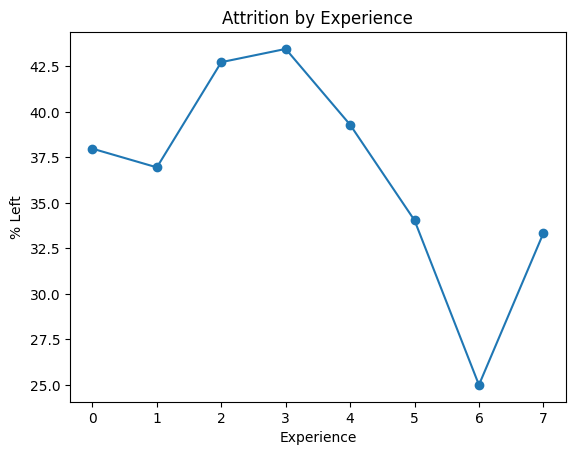

In [21]:
# visualize important attrition


# payment tier
tier_attrition = pd.crosstab(
    data['paymenttier'],
    data['attrition'],
    normalize='index')*100

tier_attrition['Left'].plot(kind="bar")
plt.title('Attrition by Payment Tier')
plt.xlabel('Payment Tier')
plt.ylabel('Percentage of employees left')
plt.show()



# ever benched
bench_attrition = pd.crosstab(
    data['everbenched'],
    data['attrition'],
    normalize='index')*100

bench_attrition['Left'].plot(kind="bar")
plt.title('Attrition by Payment Bench status')
plt.xlabel('Benched')
plt.ylabel('Percentage of employees left')
plt.show()


# age distribution
plt.figure(figsize=(8,5))
sns.boxplot(x='attrition',y='age',data=data)
plt.title('Age Distribution by Attrition')
plt.show()


# city attrition
city_attrition = pd.crosstab(
    data['city'],
    data['attrition'],
    normalize='index'
)*100


city_attrition['Left'].plot(kind='bar')

plt.title('Attrition by City')
plt.ylabel("Attrition")
plt.xlabel("City")
plt.show()



# attrition by experience
experience_attrition = (data.groupby('experienceincurrentdomain')['leaveornot'].mean()*100)
experience_attrition.plot(marker='o')

plt.title('Attrition by Experience')

plt.ylabel('% Left')
plt.xlabel('Experience')

plt.show()
